# Задача № 2

Давайте соберем информацию о друзьях и друзьях друзей из VK для членов Вашей группы.
Оценить центральность: по посредничеству, по близости, собственного вектора (только для членов Вашей группы).


### Подтверждение завершённого сбора

Сбор совершает модуль vk_collect


In [1]:
from pathlib import Path
import re

log_path = Path('collect.log')
if not log_path.exists():
    print('Журнал сбора отсутствует; используем только сохранённый CSV.')
else:
    completion_line = next(
        (
            line.strip()
            for line in log_path.open(encoding='utf-8')
            if 'Collection complete:' in line
        ),
        None,
    )
    counts = re.search(
        (
            r'Collection complete: level 0=(\d+), level 1=(\d+), '
            r'level 2=(\d+), edges=(\d+)'
        ),
        completion_line or '',
    )
    if counts:
        print(
            f'Сбор завершён: участников — {counts[1]}, прямых ID — {counts[2]}, '
            f'второй круг — {counts[3]}, наблюдений — {counts[4]}'
        )
        collected_at = re.search(r'\d{4}-\d{2}-\d{2}', completion_line)
        if collected_at:
            print(f'Дата завершения: {collected_at[0]}')
    else:
        print('Collection log has no recognized completion summary.')


Сбор завершён: участников — 4, прямых ID — 344, второй круг — 61221, наблюдений — 67798
Дата завершения: 2026-09-30


В журнале 344 ID прямых друзей, включая некоторых участников группы; без участников это 341 уникальный человек. 384 связи «прямой друг–участник» включают пересечения между списками.

### Библиотеки и параметры

Фиксируем участников, цвета и схему входных данных. Исходные имена полей используются далее только внутри кода.


In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import display

GROUP_MEMBERS = {
    198182178: 'flashik12',
    473310225: '0pupok00',
    424935969: 'ryosuk3',
    465105120: 'medvediano',
}
PARENT_COLORS = {
    'flashik12': '#1f77b4',
    '0pupok00': '#2ca02c',
    'ryosuk3': '#ff7f0e',
    'medvediano': '#ff69b4',
}
DATA_DIR = Path('data')
CSV_PATH = DATA_DIR / 'vk_friends_full.csv'
REQUIRED_COLUMNS = {
    'user_id', 'friend_id', 'observation_level', 'friend_first_name',
    'friend_last_name', 'friend_screen_name', 'friend_discovery_level',
    'friend_parent_ids', 'friend_via_friend_ids', 'friend_friends_status',
    'friend_friends_count',
}


### Чтение и контроль CSV

Проверяем обязательные поля, идентификаторы и уровни наблюдений. Удаляются только полностью повторяющиеся записи.


In [3]:
if not CSV_PATH.exists():
    raise FileNotFoundError(f'Required input CSV does not exist: {CSV_PATH}')

raw_edges = pd.read_csv(CSV_PATH)
missing_columns = REQUIRED_COLUMNS.difference(raw_edges.columns)
if missing_columns:
    raise ValueError(
        f'CSV schema is missing required columns: {sorted(missing_columns)}'
    )

prepared_edges = raw_edges.copy()
integer_columns = (
    'user_id', 'friend_id', 'observation_level', 'friend_discovery_level'
)
for column in integer_columns:
    values = pd.to_numeric(prepared_edges[column], errors='coerce')
    if values.isna().any() or not (values % 1 == 0).all():
        raise ValueError(f'CSV column {column} must contain integers')
    prepared_edges[column] = values.astype('int64')

if (prepared_edges[['user_id', 'friend_id']] <= 0).any().any():
    raise ValueError('CSV identifiers must be positive integers')
if not prepared_edges['observation_level'].isin([1, 2]).all():
    raise ValueError('CSV observation_level must be 1 or 2')
if not prepared_edges['friend_discovery_level'].isin([0, 1, 2]).all():
    raise ValueError('CSV friend_discovery_level must be 0, 1, or 2')

input_row_count = len(raw_edges)
prepared_edges = prepared_edges.drop_duplicates().reset_index(drop=True)


В сохранённой выгрузке 67 798 строк; следующая таблица показывает результат проверки и удаления точных дублей.

### Размер исходной и подготовленной таблицы


In [4]:
row_summary = pd.DataFrame([
    {'Этап': 'Строки во входном CSV', 'Количество': input_row_count},
    {'Этап': 'Строки после проверки', 'Количество': len(prepared_edges)},
    {
        'Этап': 'Удалено полных дублей',
        'Количество': input_row_count - len(prepared_edges),
    },
])
display(row_summary)


,Этап,Количество
0,Строки во входном CSV,67798
1,Строки после проверки,67798
2,Удалено полных дублей,0


Отсутствующие имена означают неполные сведения профиля; незагруженный список друзей — недоступность или отсутствие запроса. Число друзей второго круга намеренно не запрашивалось и является неприменимым, а не нулевым.

### Смысловые пропуски


In [5]:
second_level_mask = prepared_edges['friend_discovery_level'].eq(2)
missing_summary = pd.DataFrame([
    {
        'Ситуация': 'Не указана фамилия друга',
        'Строк': int(prepared_edges['friend_last_name'].isna().sum()),
    },
    {
        'Ситуация': 'Список друзей закрыт или не загружен',
        'Строк': int(prepared_edges['friend_friends_status'].ne('loaded').sum()),
    },
    {
        'Ситуация': 'Список друзей второго круга не запрашивался',
        'Строк': int(
            (second_level_mask & prepared_edges['friend_friends_count'].isna()).sum()
        ),
    },
])
display(missing_summary)


,Ситуация,Строк
0,Не указана фамилия друга,555
1,Список друзей закрыт или не загружен,66756
2,Список друзей второго круга не запрашивался,65877


### Построение полного графа

Каждую наблюдаемую пару приводим к каноническому порядку, чтобы взаимные наблюдения стали одним неориентированным ребром. Вершины участников добавляются явно.


In [6]:
edge_endpoints = prepared_edges[['user_id', 'friend_id']]
canonical_edges = pd.DataFrame({
    'source': edge_endpoints.min(axis=1),
    'target': edge_endpoints.max(axis=1),
}).drop_duplicates()

G = nx.Graph()
G.add_edges_from(canonical_edges.itertuples(index=False, name=None))
G.add_nodes_from(GROUP_MEMBERS)


В полном графе 61 566 вершин и 67 300 неориентированных рёбер. Число строк наблюдений больше числа рёбер, так как связь может попасть в несколько списков.

### Размер полного графа


In [7]:
graph_summary = pd.DataFrame([
    {'Показатель': 'Вершины полного графа', 'Количество': G.number_of_nodes()},
    {'Показатель': 'Неориентированные рёбра', 'Количество': G.number_of_edges()},
])
display(graph_summary)


,Показатель,Количество
0,Вершины полного графа,61566
1,Неориентированные рёбра,67300


Для участников берём имена из карточек endpoint в CSV, статус списка — из `friend_friends_status` той же карточки. Степень в полном графе отражает число уникальных соседей, наблюдаемых в любой стороне связи.

### Четыре участника


In [8]:
member_rows = []
for member_id, screen_name in GROUP_MEMBERS.items():
    member_records = prepared_edges.loc[prepared_edges['friend_id'].eq(member_id)]
    first_names = member_records['friend_first_name'].dropna()
    last_names = member_records['friend_last_name'].dropna()
    first_name = str(first_names.iloc[0]) if not first_names.empty else ''
    last_name = str(last_names.iloc[0]) if not last_names.empty else ''
    status_values = member_records['friend_friends_status'].dropna().unique()
    if len(status_values) > 1:
        raise ValueError(f'Conflicting friend-list statuses for member {screen_name}')
    if len(status_values) == 0:
        list_status = 'Статус неизвестен'
    elif status_values[0] == 'profile_closed':
        list_status = 'Список недоступен'
    elif status_values[0] == 'loaded':
        list_status = 'Список получен'
    else:
        list_status = 'Список не получен'
    member_rows.append({
        'Участник': screen_name,
        'ФИО': f'{first_name} {last_name}'.strip(),
        'Статус списка': list_status,
        'Наблюдаемые связи в графе': G.degree(member_id),
    })

members_table = pd.DataFrame(member_rows)
display(members_table)


,Участник,ФИО,Статус списка,Наблюдаемые связи в графе
0,flashik12,Alexander Ershov,Список недоступен,20
1,0pupok00,Lia Martynova,Список получен,177
2,ryosuk3,Vladimir Romanenko,Список получен,30
3,medvediano,Ilya Medvedev,Список получен,181


У `flashik12` ожидаются 20 наблюдаемых связей при недоступном собственном списке. У остальных участников степень графа отражает связи, полученные из доступных списков.

### Прямые друзья вне группы


In [9]:
direct_observations = prepared_edges.loc[
    prepared_edges['observation_level'].eq(1)
].copy()
direct_parent_observations = direct_observations.loc[
    ~direct_observations['friend_id'].isin(GROUP_MEMBERS)
].drop_duplicates(['user_id', 'friend_id'])
direct_friend_ids = set(direct_observations['friend_id']) - set(GROUP_MEMBERS)
direct_summary = pd.DataFrame([{
    'Уникальные прямые друзья вне группы': len(direct_friend_ids),
    'Связи прямой друг–участник вне группы': len(direct_parent_observations),
}])
display(direct_summary)


,Уникальные прямые друзья вне группы,Связи прямой друг–участник вне группы
0,341,384


### Примеры общих прямых друзей

В таблице — реальные профили CSV, встречающиеся в списках двух или более участников. Примеры отсортированы по числу участников, затем по ID для воспроизводимости; идентификаторы в таблице не показываются.


In [10]:
parent_sets = direct_parent_observations.groupby('friend_id')['user_id'].agg(set)
shared_parent_sets = {
    int(friend_id): parents
    for friend_id, parents in parent_sets.items()
    if len(parents) >= 2
}
profile_by_friend = (
    prepared_edges.drop_duplicates('friend_id')
    .set_index('friend_id')
)
shared_rows = []
for friend_id, parent_ids in shared_parent_sets.items():
    profile = profile_by_friend.loc[friend_id]
    first_name = profile['friend_first_name']
    last_name = profile['friend_last_name']
    first_name = '' if pd.isna(first_name) else str(first_name)
    last_name = '' if pd.isna(last_name) else str(last_name)
    full_name = f'{first_name} {last_name}'.strip() or 'Имя не указано'
    screen_name = profile['friend_screen_name']
    screen_name = 'Никнейм не указан' if pd.isna(screen_name) else str(screen_name)
    parent_names = [
        GROUP_MEMBERS[parent_id]
        for parent_id in GROUP_MEMBERS
        if parent_id in parent_ids
    ]
    if len(parent_names) != len(parent_ids):
        raise ValueError('A direct-friend parent is not a known group member')
    shared_rows.append({
        'friend_id': friend_id,
        'Имя': full_name,
        'Никнейм': screen_name,
        'Участники, у которых встречается': ', '.join(parent_names),
        'Число участников': len(parent_names),
    })
shared_rows.sort(
    key=lambda row: (-row['Число участников'], row['friend_id'])
)
shared_friend_count = len(shared_rows)
extra_parent_incidences = sum(row['Число участников'] - 1 for row in shared_rows)
direct_friend_count = len(direct_friend_ids)
parent_incidence_count = len(direct_parent_observations)
overlap_table = pd.DataFrame(shared_rows).head(5)
display(overlap_table.drop(columns='friend_id'))
print(
    f'Среди {direct_friend_count} уникальных друзей {shared_friend_count} '
    f'встречаются в нескольких списках. '
    f'Эти пересечения дают {extra_parent_incidences} дополнительных отношений: '
    f'поэтому {parent_incidence_count} отношений друг–участник превышают '
    f'{direct_friend_count} уникальных вершин.'
)


,Имя,Никнейм,"Участники, у которых встречается",Число участников
0,Alexey Rusakov,rusalm,"0pupok00, ryosuk3, medvediano",3
1,Pavel Ivakhin,qtdoge,"0pupok00, medvediano",2
2,Artyom Nikulin,artem_kaaa,"0pupok00, medvediano",2
3,Stepan Chaplygin,dedhohotun,"0pupok00, ryosuk3",2
4,Oleg Negoda,oleja_negoda,"0pupok00, medvediano",2


Среди 341 уникальных друзей 42 встречаются в нескольких списках. Эти пересечения дают 43 дополнительных отношений: поэтому 384 отношений друг–участник превышают 341 уникальных вершин.


Вне группы 341 уникальный прямой друг; отношений «друг–участник» 384 из-за пересечений. Следующая таблица — только иллюстрация записей, не полная выгрузка.

### Небольшой пример прямых друзей


In [11]:
direct_example = direct_observations[[
    'user_id', 'friend_first_name', 'friend_last_name', 'friend_screen_name'
]].drop_duplicates().sort_values(['user_id', 'friend_screen_name']).head(6).copy()
direct_example['Участник'] = direct_example['user_id'].map(GROUP_MEMBERS)
direct_example['Имя друга'] = (
    direct_example['friend_first_name'].fillna('') + ' '
    + direct_example['friend_last_name'].fillna('')
).str.strip().replace('', 'Имя не указано')
direct_example = direct_example[
    ['Участник', 'Имя друга', 'friend_screen_name']
].rename(columns={'friend_screen_name': 'Никнейм'})
display(direct_example)


,Участник,Имя друга,Никнейм
205,ryosuk3,Andrey Kabanov,andy2213
196,ryosuk3,Anna Pastukhova,annasergeyevnapastukhova
195,ryosuk3,Artem Tarasov,artar1704
202,ryosuk3,Taras Tarabarov,chilym
189,ryosuk3,Yury Kulakov,dailydegen
181,ryosuk3,Danita Chanysheva,danitaaaa


### Вершины второго круга

Считаем уникальные вершины уровня 2. Поля о родителях и посредниках остаются внутренними и нужны для короткого примера пути.


In [12]:
second_friends = prepared_edges.loc[
    prepared_edges['friend_discovery_level'].eq(2),
    [
        'friend_id', 'friend_first_name', 'friend_last_name',
        'friend_screen_name', 'friend_parent_ids', 'friend_via_friend_ids',
    ],
].drop_duplicates('friend_id')
second_friend_count = second_friends['friend_id'].nunique()
second_count_table = pd.DataFrame([{
    'Уникальные вершины второго круга': second_friend_count,
}])
display(second_count_table)


,Уникальные вершины второго круга
0,61221


В сохранённой выгрузке 61 221 уникальная вершина второго круга. Одна вершина может быть обнаружена несколькими путями.

### Пример пути во второй круг


In [13]:
screen_name_by_id = (
    prepared_edges[['friend_id', 'friend_screen_name']]
    .drop_duplicates('friend_id')
    .set_index('friend_id')['friend_screen_name']
    .to_dict()
)

def format_member_parents(value):
    """Преобразует родительские ID в ники участников для учебного примера"""
    if pd.isna(value) or not str(value).strip():
        return 'Не указан'
    names = [
        GROUP_MEMBERS.get(int(item), str(item))
        for item in str(value).split('|')
        if item
    ]
    return ', '.join(names) or 'Не указан'

def format_via_friends(value):
    """Показывает ники прямых друзей, через которых найден второй круг"""
    if pd.isna(value) or not str(value).strip():
        return 'Не указан'
    names = [
        screen_name_by_id.get(int(item), str(item))
        for item in str(value).split('|')
        if item
    ]
    return ', '.join(names) or 'Не указан'

second_example = second_friends.sort_values('friend_id').head(5).copy()
second_example['Путь через участника'] = second_example['friend_parent_ids'].map(
    format_member_parents
)
second_example['Прямой друг-посредник'] = second_example['friend_via_friend_ids'].map(
    format_via_friends
)
second_example['Имя'] = (
    second_example['friend_first_name'].fillna('') + ' '
    + second_example['friend_last_name'].fillna('')
).str.strip().replace('', 'Имя не указано')
second_example = second_example[[
    'Путь через участника', 'Прямой друг-посредник', 'Имя', 'friend_screen_name'
]].rename(columns={'friend_screen_name': 'Никнейм'})
display(second_example)


,Путь через участника,Прямой друг-посредник,Имя,Никнейм
58666,medvediano,aroundboxing,Nikita Egorov,nyegorov
38951,medvediano,id329492178,Pavel Molochko,foxhound
388,0pupok00,dmitriy_tolkunov,Evgenia Shteyman,evashteyn
9707,medvediano,id41397841,Alexander Loginov,id6754
389,0pupok00,dmitriy_tolkunov,Sonya Vaganova,sonyavaganova


### Постраничный просмотр рёбер

Функция фильтрует по любому ID из поля родителей, ограничивает страницу 50 строками и возвращает пустую таблицу с теми же русскими колонками, если страница вне диапазона.


In [14]:
def view_edges(parent, page=0, page_size=10, edges=None):
    """Возвращает ограниченную страницу наблюдений выбранного участника"""
    if parent not in GROUP_MEMBERS.values():
        raise ValueError('Unknown parent screen name')
    if page < 0 or page_size < 1:
        raise ValueError('Page must be non-negative and page_size must be positive')
    source = prepared_edges if edges is None else edges
    parent_id = next(
        member_id for member_id, name in GROUP_MEMBERS.items() if name == parent
    )
    page_size = min(int(page_size), 50)
    parent_lists = source['friend_parent_ids'].fillna('').astype(str).str.split('|')
    selected = source.loc[parent_lists.map(
        lambda parent_ids: str(parent_id) in parent_ids
    )]
    page_rows = selected.iloc[page * page_size:(page + 1) * page_size].copy()
    page_rows['Имя'] = (
        page_rows['friend_first_name'].fillna('') + ' '
        + page_rows['friend_last_name'].fillna('')
    ).str.strip().replace('', 'Имя не указано')
    return page_rows[[
        'Имя', 'friend_screen_name', 'observation_level'
    ]].rename(columns={
        'friend_screen_name': 'Никнейм',
        'observation_level': 'Круг наблюдения',
    }).reset_index(drop=True)


Пример просмотра первой страницы для `medvediano`; размер ограничен десятью строками.


In [15]:
display(view_edges('medvediano', page=0, page_size=10))


,Имя,Никнейм,Круг наблюдения
0,Pavel Ivakhin,qtdoge,1
1,Artyom Nikulin,artem_kaaa,1
2,Alexey Rusakov,rusalm,1
3,Oleg Negoda,oleja_negoda,1
4,Alexander Ershov,flashik12,1
5,Ulyana Dobrodomova,ulyalya99,1
6,Maxim Ramazanov,zap0mn1,1
7,Elnara Ravilova,elnara_ravilova,1
8,Konstantin Veselov,bratmarat8,1
9,Nellya Erenkova,nellli.ii17,1


Проверим функцию на искусственных рёбрах: два общих друга имеют разных родителей, а второй участник указан вторым в списке родителей. Исходный DataFrame выгрузки не подменяется.


In [16]:
synthetic_edges = pd.DataFrame([
    {
        'friend_parent_ids': '473310225|465105120',
        'friend_first_name': 'А',
        'friend_last_name': 'Один',
        'friend_screen_name': 'common_one',
        'observation_level': 2,
    },
    {
        'friend_parent_ids': '424935969|465105120',
        'friend_first_name': 'Б',
        'friend_last_name': 'Два',
        'friend_screen_name': 'common_two',
        'observation_level': 2,
    },
])
second_parent_page = view_edges(
    'medvediano', page=0, page_size=50, edges=synthetic_edges
)
assert second_parent_page['Никнейм'].tolist() == ['common_one', 'common_two']
assert view_edges(
    'medvediano', page=1, page_size=50, edges=synthetic_edges
).empty


### Сравнение открытых списков

Столбцы показывают число уникальных прямых друзей трёх участников с полученным списком. Закрытый список `flashik12` не изображается нулём; его статус и 20 наблюдаемых связей указаны в таблице участников.


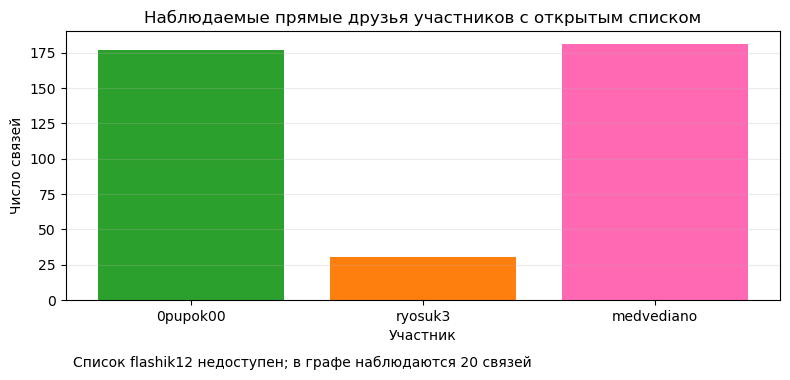

In [17]:
open_members = members_table.loc[
    members_table['Статус списка'].eq('Список получен')
]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    open_members['Участник'],
    open_members['Наблюдаемые связи в графе'],
    color=[PARENT_COLORS[name] for name in open_members['Участник']],
)
ax.set_title('Наблюдаемые прямые друзья участников с открытым списком')
ax.set_xlabel('Участник')
ax.set_ylabel('Число связей')
ax.text(
    0.01, -0.25,
    'Список flashik12 недоступен; в графе наблюдаются 20 связей',
    transform=ax.transAxes,
)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()


По сохранённой выгрузке у `medvediano` 181 прямой друг, на 4 больше, чем у `0pupok00` (177); у `ryosuk3` — 30. `flashik12` в сравнении не считается нулём: его список недоступен, а 20 связей наблюдаются только в чужих списках.

### Детерминированный обзорный подграф

Для рисунка включаем участников, прямых друзей и до 305 вершин второго круга, выбранных по убыванию степени полного графа с ID для разрешения равенств. При пересечении прямых списков цвет задаёт первый родитель в каноническом порядке участников.


In [18]:
member_ids = set(GROUP_MEMBERS)
second_ids = set(second_friends['friend_id']) - member_ids - direct_friend_ids
second_by_degree = sorted(second_ids, key=lambda node: (-G.degree(node), node))
selected_second_ids = set(second_by_degree[:305])
shown_ids = member_ids | direct_friend_ids | selected_second_ids
H = G.subgraph(shown_ids).copy()

member_parent_by_id = {
    member_id: screen_name for member_id, screen_name in GROUP_MEMBERS.items()
}
direct_parent_ids = {}
for _, row in direct_parent_observations.iterrows():
    friend_id = int(row['friend_id'])
    member_id = int(row['user_id'])
    if friend_id not in member_ids:
        direct_parent_ids.setdefault(friend_id, set()).add(member_id)
member_order = list(GROUP_MEMBERS)
canonical_parent = {
    friend_id: next(
        member_id for member_id in member_order
        if member_id in parent_ids
    )
    for friend_id, parent_ids in direct_parent_ids.items()
}


Проверяем, что обзор не превышает 650 вершин; ниже показывается одна таблица сравнения размеров полного и отображаемого графа.

### Полный и показанный граф


In [19]:
shown_summary = pd.DataFrame([{
    'Вершины полного графа': G.number_of_nodes(),
    'Рёбра полного графа': G.number_of_edges(),
    'Вершины на рисунке': H.number_of_nodes(),
    'Рёбра на рисунке': H.number_of_edges(),
}])
if H.number_of_nodes() > 650:
    raise ValueError('Overview graph exceeds the 650-node budget')
display(shown_summary)


,Вершины полного графа,Рёбра полного графа,Вершины на рисунке,Рёбра на рисунке
0,61566,67300,650,2934


Четыре участника выделены крупными подписанными узлами. Прямые друзья окрашены по каноническому родителю, второй круг показан серым. Технические ID не отображаются.

### Обзор связей


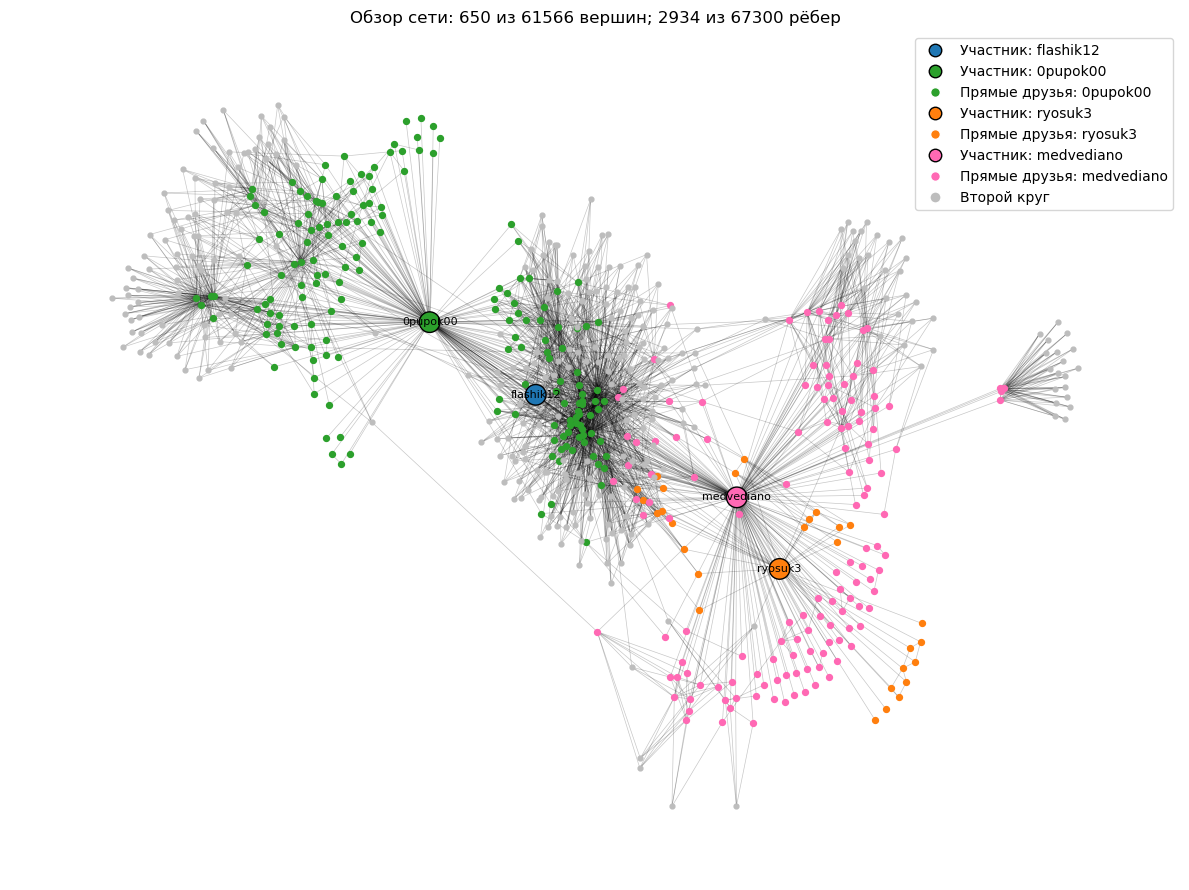

В примере общих друзей — Alexey Rusakov (@rusalm): он встречается у 0pupok00, ryosuk3, medvediano; всего в нескольких списках найдены 42 друга.


In [20]:
positions = nx.spring_layout(H, seed=42, iterations=35)
fig, ax = plt.subplots(figsize=(12, 9))
nx.draw_networkx_edges(H, positions, alpha=0.22, width=0.5, ax=ax)

parent_nodes_by_name = {}
for parent_name, color in PARENT_COLORS.items():
    parent_id = next(
        member_id for member_id, name in GROUP_MEMBERS.items()
        if name == parent_name
    )
    parent_nodes = [
        node for node, selected_parent in canonical_parent.items()
        if selected_parent == parent_id and node in H
    ]
    parent_nodes_by_name[parent_name] = parent_nodes
    nx.draw_networkx_nodes(
        H, positions, nodelist=parent_nodes, node_color=color,
        node_size=18, ax=ax,
    )

nx.draw_networkx_nodes(
    H, positions, nodelist=list(selected_second_ids & set(H)),
    node_color='#bdbdbd', node_size=12, ax=ax,
)
nx.draw_networkx_nodes(
    H, positions, nodelist=list(member_ids),
    node_color=[PARENT_COLORS[GROUP_MEMBERS[node]] for node in member_ids],
    node_size=220, edgecolors='black', linewidths=1.0, ax=ax,
)
member_labels = {node: GROUP_MEMBERS[node] for node in member_ids}
nx.draw_networkx_labels(
    H, positions, labels=member_labels, font_size=8,
    font_color='black', ax=ax,
)
legend_handles = []
for name, color in PARENT_COLORS.items():
    legend_handles.append(plt.Line2D(
        [0], [0], marker='o', color='w', markerfacecolor=color,
        markeredgecolor='black', label=f'Участник: {name}', markersize=9,
    ))
    if parent_nodes_by_name[name]:
        legend_handles.append(plt.Line2D(
            [0], [0], marker='o', color='w', markerfacecolor=color,
            label=f'Прямые друзья: {name}', markersize=7,
        ))
legend_handles.append(plt.Line2D(
    [0], [0], marker='o', color='w', markerfacecolor='#bdbdbd',
    label='Второй круг', markersize=8,
))
ax.legend(handles=legend_handles, loc='upper right')
ax.set_title(
    f'Обзор сети: {H.number_of_nodes()} из {G.number_of_nodes()} вершин; '
    f'{H.number_of_edges()} из {G.number_of_edges()} рёбер'
)
ax.axis('off')
fig.tight_layout()
fig.savefig(DATA_DIR / 'graph.png', dpi=180, bbox_inches='tight')
plt.show()
if overlap_table.empty:
    print('В прямых списках нет общих друзей вне группы.')
else:
    shared_example = overlap_table.iloc[0]
    print(
        f"В примере общих друзей — {shared_example['Имя']} "
        f"(@{shared_example['Никнейм']}): он встречается у "
        f"{shared_example['Участники, у которых встречается']}; "
        f"всего в нескольких списках найдены {shared_friend_count} друга."
    )


На рисунке показана выборка 650 из 61 566 вершин: участники, прямой круг и выбранные по наибольшей степени вершины второго круга. Поэтому плотность этого изображения нельзя переносить на весь граф. Цвет прямого друга соответствует его каноническому участнику-родителю, второй круг серый. В таблице выше показано фактическое пересечение списков; все центральности далее вычисляются на полном графе `G`.

### Самопроверка метрик и графа

На пути из четырёх узлов близость вершин 0 и 3 равна 0,5, вершин 1 и 2 — 0,75. Также проверяем количество узлов и рёбер и наличие общего друга.


In [21]:
test_graph = nx.path_graph(4)
expected_closeness = {0: 0.5, 1: 0.75, 2: 0.75, 3: 0.5}
actual_closeness = {
    node: nx.closeness_centrality(test_graph, u=node)
    for node in expected_closeness
}
assert test_graph.number_of_nodes() == 4
assert test_graph.number_of_edges() == 3
assert actual_closeness == expected_closeness
assert set(test_graph.neighbors(0)) & set(test_graph.neighbors(2)) == {1}
print('Синтетическая проверка графа и точной близости пройдена.')


Синтетическая проверка графа и точной близости пройдена.


### Центральности четырёх участников на полном графе

Посредничество оценивает долю кратчайших путей через вершину; нормировка соответствует NetworkX для неориентированного графа. Оно приближённое: `k=128`, seed 42, обязательный backend `cugraph`; ошибка GPU прерывает выполнение. Близость — обратная средняя длина кратчайших путей до достижимых вершин, вычисляется точно отдельно для каждого участника. Собственный вектор оценивает связь с влиятельными соседями и вычисляется разреженным SciPy-методом.


In [22]:
try:
    betweenness = nx.betweenness_centrality(
        G,
        k=min(128, len(G)),
        seed=42,
        backend='cugraph',
    )
except Exception as error:
    raise RuntimeError('GPU betweenness centrality backend cugraph failed') from error

closeness = {
    member_id: nx.closeness_centrality(G, u=member_id)
    for member_id in GROUP_MEMBERS
}
eigenvector = nx.eigenvector_centrality_numpy(G)
centrality = pd.DataFrame([
    {
        'Участник': screen_name,
        'Посредничество (приближённое)': betweenness[member_id],
        'Близость (точная)': closeness[member_id],
        'Собственный вектор': eigenvector[member_id],
    }
    for member_id, screen_name in GROUP_MEMBERS.items()
])
export_rows = []
for member_id, screen_name in GROUP_MEMBERS.items():
    closed = members_table.loc[
        members_table['Участник'].eq(screen_name), 'Статус списка'
    ].iloc[0] == 'Список недоступен'
    export_rows.append({
        'participant': screen_name,
        'degree': G.degree(member_id),
        'observed_links': G.degree(member_id),
        'betweenness_approximate': betweenness[member_id],
        'closeness_exact_cpu': closeness[member_id],
        'eigenvector_sparse_scipy': eigenvector[member_id],
        'reason': (
            'Closed profile: own friend list is unavailable; '
            'observed incoming links remain included.'
            if closed else ''
        ),
    })
pd.DataFrame(export_rows).to_csv(DATA_DIR / 'member_centrality.csv', index=False)
display(centrality)


,Участник,Посредничество (приближённое),Близость (точная),Собственный вектор
0,flashik12,0.002156,0.341156,0.018857
1,0pupok00,0.333934,0.389196,0.043752
2,ryosuk3,0.014440,0.268244,0.011143
3,medvediano,0.661100,0.426874,0.036961


Сопоставим четыре участника по каждой центральности на отдельном рисунке: шкалы и смысл метрик различаются.

### Графическое сравнение мер


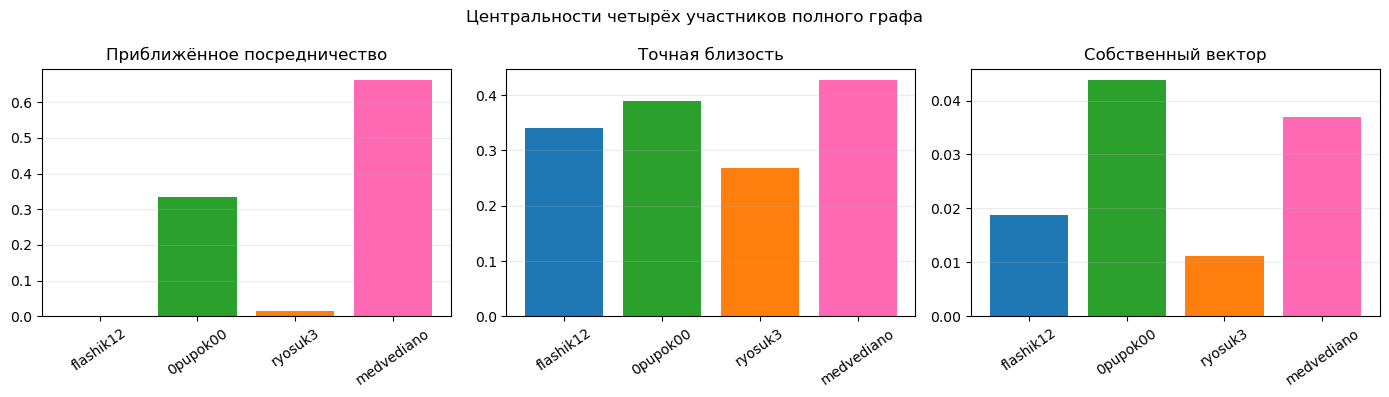

In [23]:
metric_titles = [
    ('Посредничество (приближённое)', 'Приближённое посредничество'),
    ('Близость (точная)', 'Точная близость'),
    ('Собственный вектор', 'Собственный вектор'),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, (column, title) in zip(axes, metric_titles):
    axis.bar(
        centrality['Участник'], centrality[column],
        color=[PARENT_COLORS[name] for name in centrality['Участник']],
    )
    axis.set_title(title)
    axis.tick_params(axis='x', rotation=35)
    axis.grid(axis='y', alpha=0.25)
fig.suptitle('Центральности четырёх участников полного графа')
fig.tight_layout()
plt.show()


## Выводы по заданию

Сопоставим максимумы трёх мер по актуальной таблице центральностей. Каждая мера отвечает на отдельный вопрос; общего рейтинга участников из них не составляем. Посредничество приближённое (`k=128`, GPU), близость точная для четырёх участников. Результат для закрытого профиля `flashik12` ограничен 20 наблюдаемыми связями из чужих списков.


In [ ]:
metric_columns = [
    'Посредничество (приближённое)',
    'Близость (точная)',
    'Собственный вектор',
]
maximum_rows = {
    column: centrality.loc[centrality[column].idxmax()]
    for column in metric_columns
}
for column, row in maximum_rows.items():
    print(
        f"Максимум «{column}» у {row['Участник']}: "
        f"{row[column]:.6f}."
    )
betweenness_leader = maximum_rows['Посредничество (приближённое)']['Участник']
closeness_leader = maximum_rows['Близость (точная)']['Участник']
eigenvector_leader = maximum_rows['Собственный вектор']['Участник']
if betweenness_leader == closeness_leader:
    print(
        f'{betweenness_leader} имеет наибольшие посредничество и близость, '
        f'а {eigenvector_leader} — наибольший собственный вектор.'
    )
else:
    print(
        f'Лидеры различаются: посредничество — {betweenness_leader}, '
        f'близость — {closeness_leader}, '
        f'собственный вектор — {eigenvector_leader}.'
    )
print(
    'Закрытый список flashik12 не позволяет считать наблюдаемые 20 связей '
    'полным числом друзей и ограничивает интерпретацию его центральностей.'
)


Максимум «Посредничество (приближённое)» у medvediano: 0.661100.
Максимум «Близость (точная)» у medvediano: 0.426874.
Максимум «Собственный вектор» у 0pupok00: 0.043752.
medvediano имеет наибольшие посредничество и близость, а 0pupok00 — наибольший собственный вектор.
Закрытый список flashik12 не позволяет считать наблюдаемые 20 связей полным числом друзей и ограничивает интерпретацию его центральностей.


Посредничество — насколько часто человек оказывается «мостиком» между другими людьми. 

Близость — сколько шагов дружбы в среднем нужно, чтобы добраться от человека до остальных: друг — один шаг, друг друга — два

Собственный вектор — насколько хорошо связаны сами друзья человека